In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("Number of transactions:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of transactions: 284807
Number of columns: 31


In [4]:
class_counts = df["Class"].value_counts()

print("Legitimate transactions:", class_counts[0])
print("Fraudulent transactions:", class_counts[1])

Legitimate transactions: 284315
Fraudulent transactions: 492


In [5]:
fraud_percentage = (df["Class"].sum() / len(df)) * 100

print("Fraud percentage:", fraud_percentage)

Fraud percentage: 0.1727485630620034


In [6]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

Total missing values: 0


In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


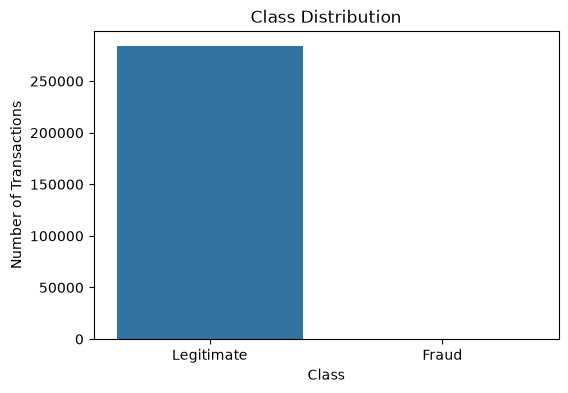

In [8]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.show()

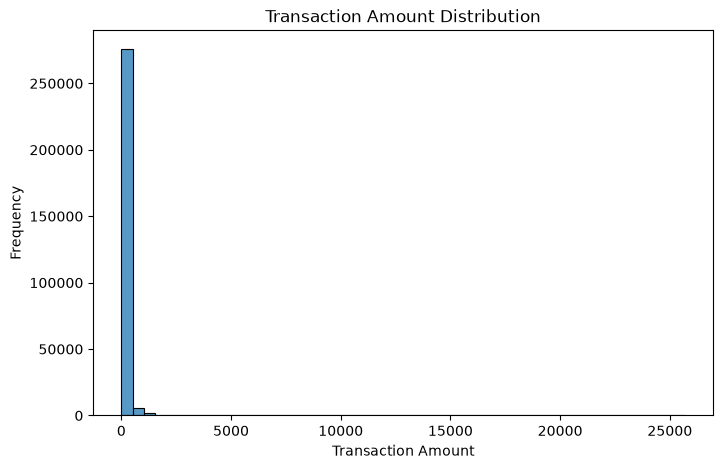

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

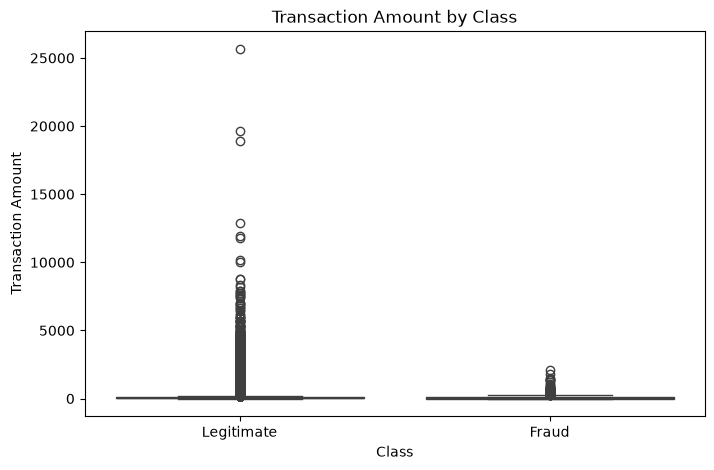

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Transaction Amount")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.show()

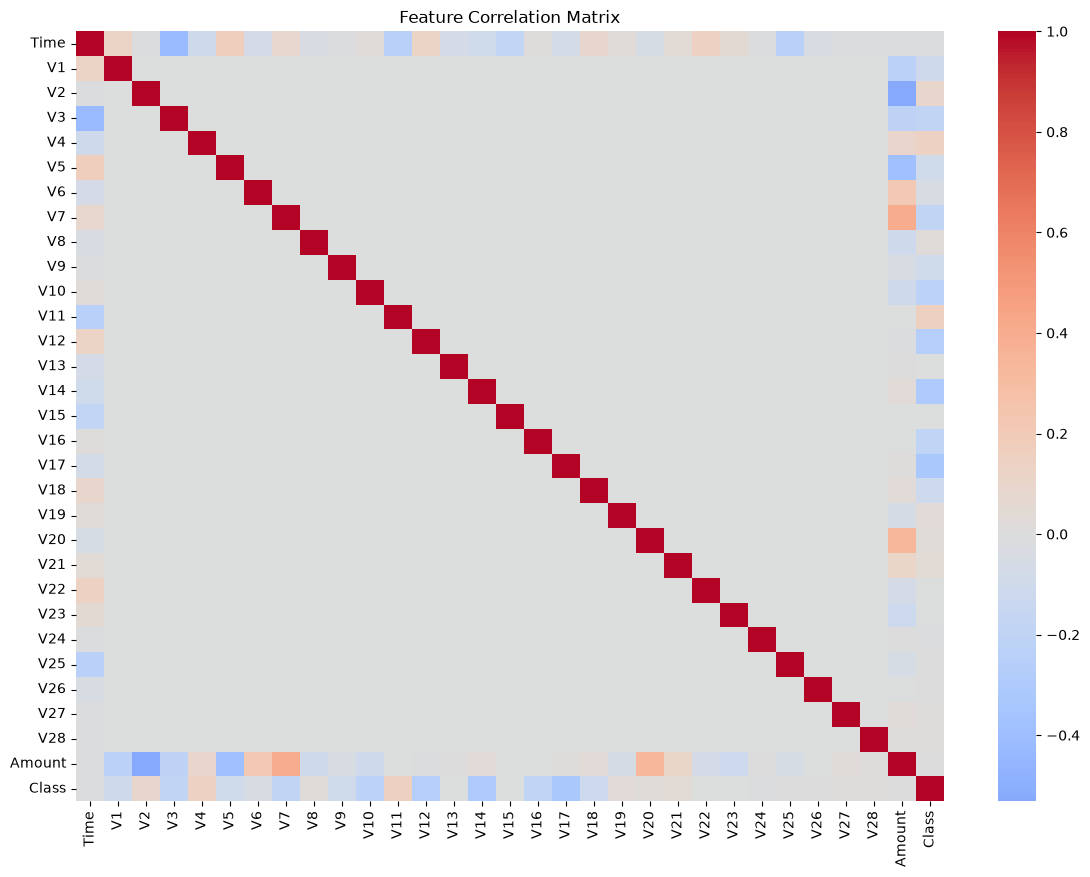

In [11]:
plt.figure(figsize=(14, 10))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

In [12]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


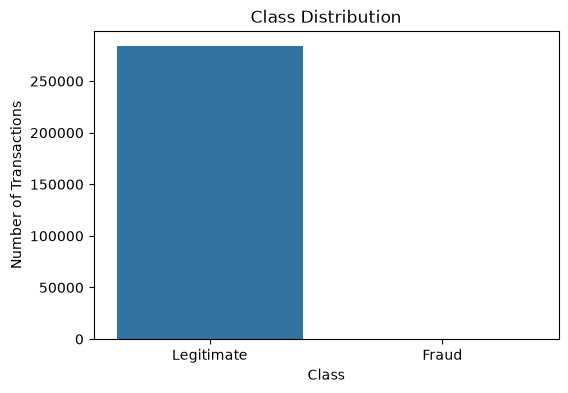

In [13]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.show()


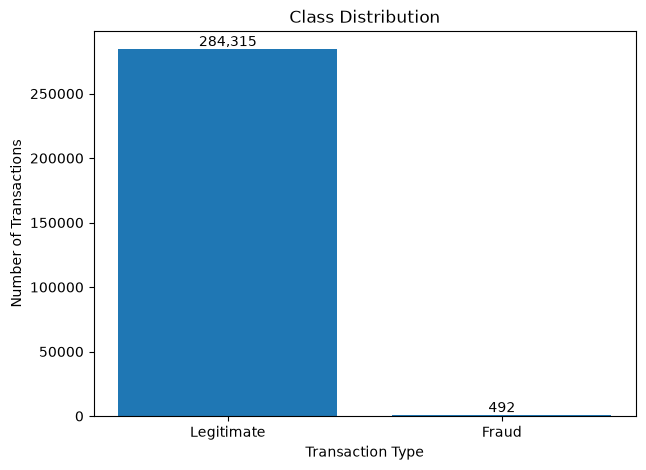

In [14]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Legitimate", "Fraud"],
    [class_counts[0], class_counts[1]]
)

plt.title("Class Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.show()

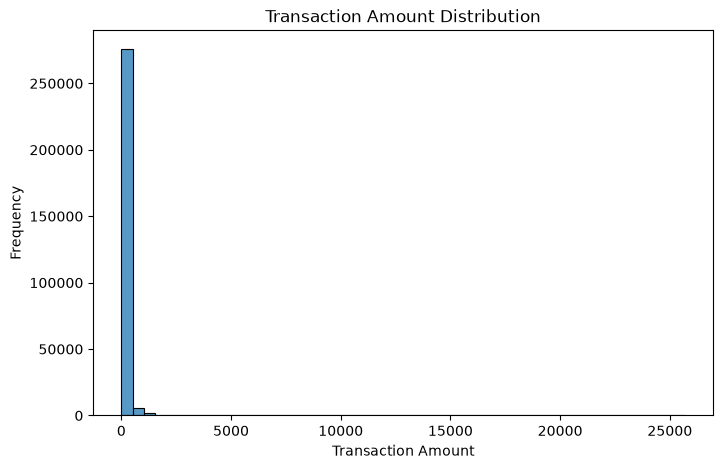

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

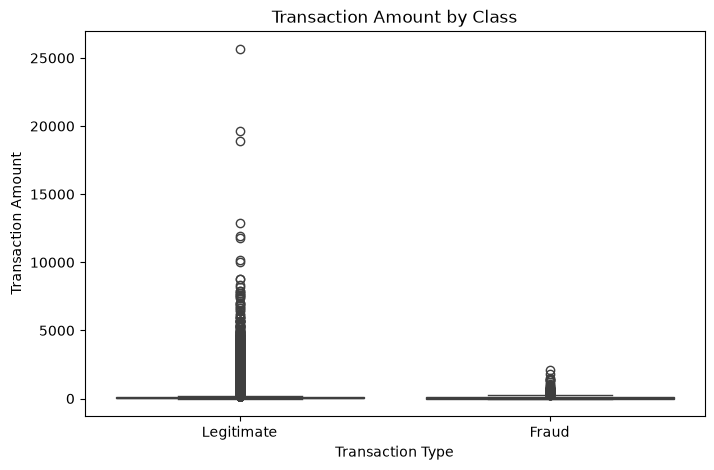

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.show()

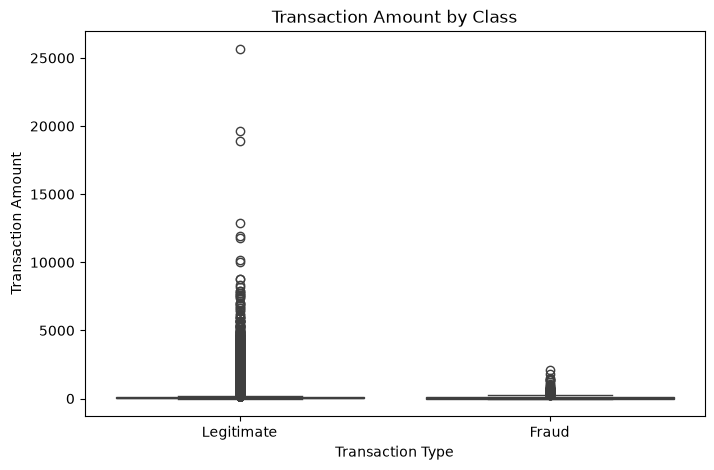

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.show()

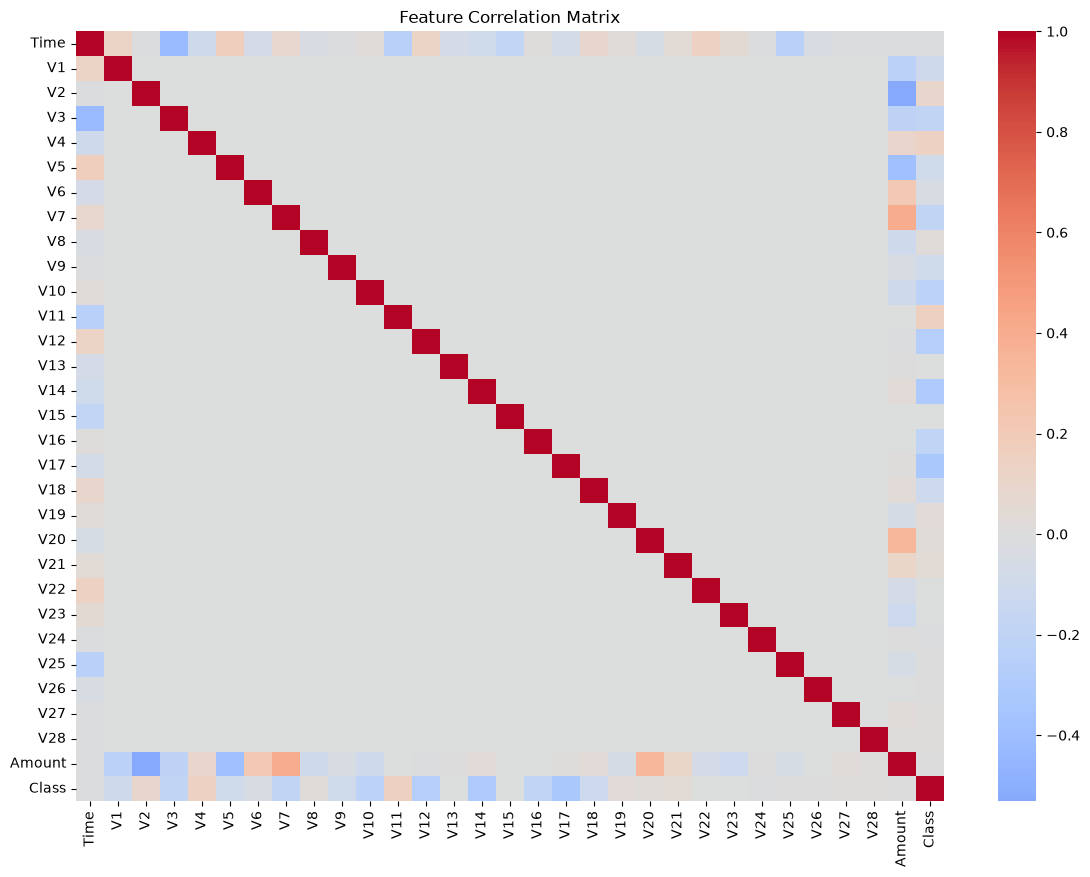

In [18]:
correlation_matrix = df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

In [19]:
correlation_with_class = df.corr()["Class"].sort_values(ascending=False)

print(correlation_with_class)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [20]:
print("Most positively correlated features with fraud:")
print(correlation_with_class.head(6))

print("\nMost negatively correlated features with fraud:")
print(correlation_with_class.tail(6))

Most positively correlated features with fraud:
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
Name: Class, dtype: float64

Most negatively correlated features with fraud:
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


In [21]:
legitimate = df[df["Class"] == 0]
fraud = df[df["Class"] == 1]

print("Legitimate transactions:", len(legitimate))
print("Fraudulent transactions:", len(fraud))

Legitimate transactions: 284315
Fraudulent transactions: 492


In [22]:
print("Average legitimate transaction amount:",
      legitimate["Amount"].mean())

print("Average fraudulent transaction amount:",
      fraud["Amount"].mean())

Average legitimate transaction amount: 88.29102242231328
Average fraudulent transaction amount: 122.21132113821139


In [23]:
print("Median legitimate transaction amount:",
      legitimate["Amount"].median())

print("Median fraudulent transaction amount:",
      fraud["Amount"].median())

Median legitimate transaction amount: 22.0
Median fraudulent transaction amount: 9.25


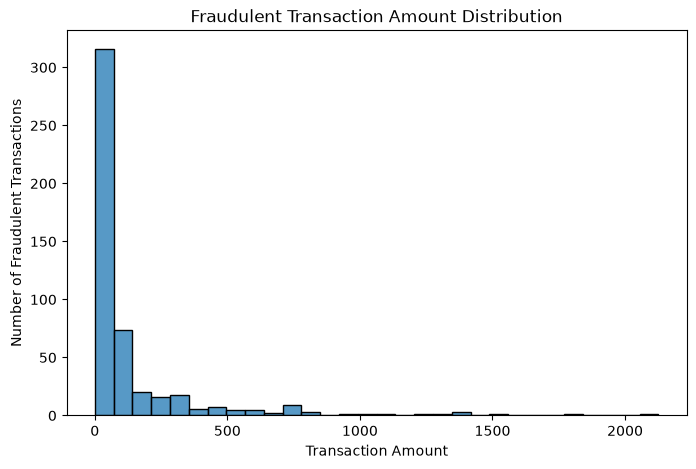

In [24]:
plt.figure(figsize=(8, 5))

sns.histplot(fraud["Amount"], bins=30)

plt.title("Fraudulent Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Fraudulent Transactions")

plt.show()

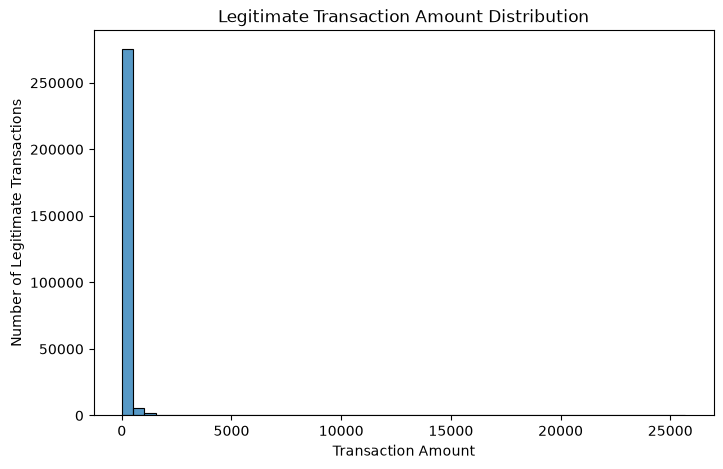

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(legitimate["Amount"], bins=50)

plt.title("Legitimate Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Legitimate Transactions")

plt.show()

In [26]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1081


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [28]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nFraud in training:", y_train.sum())
print("Fraud in testing:", y_test.sum())

Training samples: 227845
Testing samples: 56962

Fraud in training: 394
Fraud in testing: 98


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data scaled:", X_train_scaled.shape)
print("Testing data scaled:", X_test_scaled.shape)

Training data scaled: (227845, 30)
Testing data scaled: (56962, 30)


In [31]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression training complete!")

Logistic Regression training complete!


In [32]:
y_pred = logistic_model.predict(X_test_scaled)

y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated!")

Predictions generated!


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



[[56851    13]
 [   36    62]]


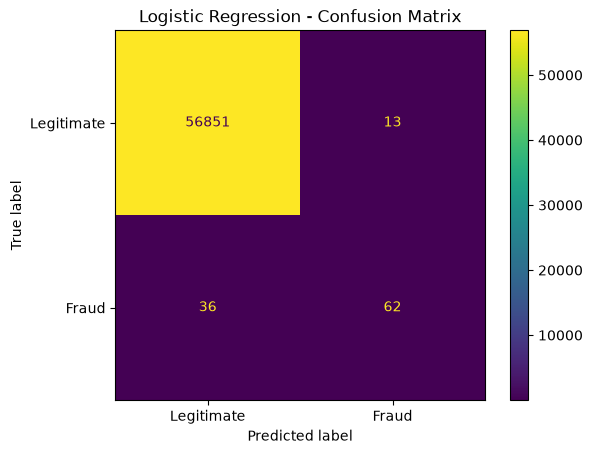

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [35]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

Precision: 0.8266666666666667
Recall: 0.6326530612244898
F1-score: 0.7167630057803468
ROC-AUC: 0.9605494455801453
PR-AUC: 0.7413820992780461


In [36]:
logistic_results = {
    "model": "Logistic Regression",
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "roc_auc": roc_auc,
    "pr_auc": pr_auc
}

logistic_results

{'model': 'Logistic Regression',
 'precision': 0.8266666666666667,
 'recall': 0.6326530612244898,
 'f1_score': 0.7167630057803468,
 'roc_auc': 0.9605494455801453,
 'pr_auc': 0.7413820992780461}

In [37]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

random_forest_model.fit(X_train, y_train)

print("Random Forest training complete!")

Random Forest training complete!


In [38]:
rf_pred = random_forest_model.predict(X_test)

rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated!")

Random Forest predictions generated!


In [39]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.91      0.79      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



[[56856     8]
 [   21    77]]


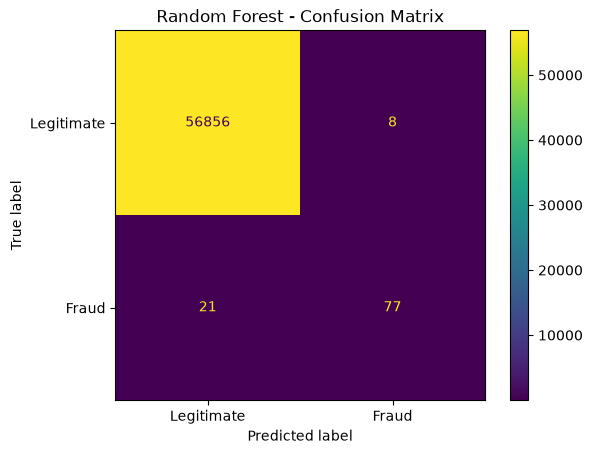

In [40]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

rf_disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Legitimate", "Fraud"]
)

rf_disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [41]:
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)
rf_pr_auc = average_precision_score(y_test, rf_prob)

print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1-score:", rf_f1)
print("ROC-AUC:", rf_roc_auc)
print("PR-AUC:", rf_pr_auc)

Precision: 0.9058823529411765
Recall: 0.7857142857142857
F1-score: 0.8415300546448088
ROC-AUC: 0.9573108734912085
PR-AUC: 0.862939836265611


In [42]:
random_forest_results = {
    "model": "Random Forest",
    "precision": rf_precision,
    "recall": rf_recall,
    "f1_score": rf_f1,
    "roc_auc": rf_roc_auc,
    "pr_auc": rf_pr_auc
}

random_forest_results

{'model': 'Random Forest',
 'precision': 0.9058823529411765,
 'recall': 0.7857142857142857,
 'f1_score': 0.8415300546448088,
 'roc_auc': 0.9573108734912085,
 'pr_auc': 0.862939836265611}

In [43]:
from xgboost import XGBClassifier

print("XGBoost imported successfully!")

XGBoost imported successfully!


In [44]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Legitimate transactions:", negative_count)
print("Fraudulent transactions:", positive_count)
print("Scale pos weight:", scale_pos_weight)


Legitimate transactions: 227451
Fraudulent transactions: 394
Scale pos weight: 577.2868020304569


In [45]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

print("XGBoost model created!")

XGBoost model created!


In [46]:
xgb_model.fit(X_train, y_train)

print("XGBoost training complete!")

XGBoost training complete!


In [47]:
xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost predictions generated!")

XGBoost predictions generated!


In [48]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.35      0.86      0.50        98

    accuracy                           1.00     56962
   macro avg       0.68      0.93      0.75     56962
weighted avg       1.00      1.00      1.00     56962



[[56711   153]
 [   14    84]]


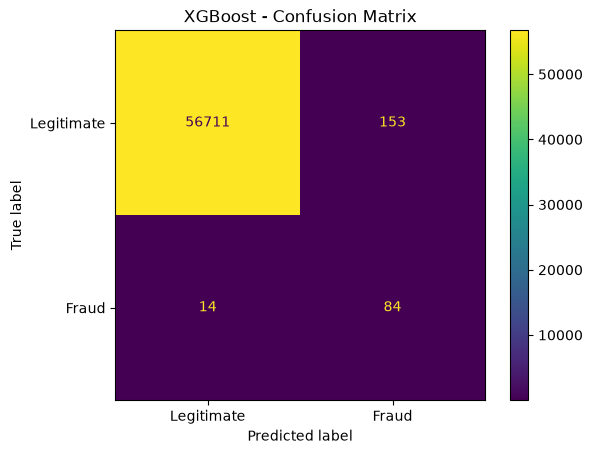

In [49]:
xgb_cm = confusion_matrix(y_test, xgb_pred)

print(xgb_cm)

xgb_disp = ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm,
    display_labels=["Legitimate", "Fraud"]
)

xgb_disp.plot()
plt.title("XGBoost - Confusion Matrix")
plt.show()

In [50]:
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_prob)
xgb_pr_auc = average_precision_score(y_test, xgb_prob)

print("Precision:", xgb_precision)
print("Recall:", xgb_recall)
print("F1-score:", xgb_f1)
print("ROC-AUC:", xgb_roc_auc)
print("PR-AUC:", xgb_pr_auc)

Precision: 0.35443037974683544
Recall: 0.8571428571428571
F1-score: 0.5014925373134328
ROC-AUC: 0.9732506237582259
PR-AUC: 0.7867211569202418


In [51]:
xgb_results = {
    "model": "XGBoost",
    "precision": xgb_precision,
    "recall": xgb_recall,
    "f1_score": xgb_f1,
    "roc_auc": xgb_roc_auc,
    "pr_auc": xgb_pr_auc
}

xgb_results

{'model': 'XGBoost',
 'precision': 0.35443037974683544,
 'recall': 0.8571428571428571,
 'f1_score': 0.5014925373134328,
 'roc_auc': 0.9732506237582259,
 'pr_auc': 0.7867211569202418}

In [52]:
results = pd.DataFrame([
    logistic_results,
    random_forest_results,
    xgb_results
])

results

,model,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression,0.826667,0.632653,0.716763,0.960549,0.741382
1,Random Forest,0.905882,0.785714,0.841530,0.957311,0.862940
2,XGBoost,0.354430,0.857143,0.501493,0.973251,0.786721


In [53]:
results.sort_values(
    by="f1_score",
    ascending=False
)

,model,precision,recall,f1_score,roc_auc,pr_auc
1,Random Forest,0.905882,0.785714,0.841530,0.957311,0.862940
0,Logistic Regression,0.826667,0.632653,0.716763,0.960549,0.741382
2,XGBoost,0.354430,0.857143,0.501493,0.973251,0.786721


In [54]:
results.sort_values(
    by="pr_auc",
    ascending=False
)

,model,precision,recall,f1_score,roc_auc,pr_auc
1,Random Forest,0.905882,0.785714,0.841530,0.957311,0.862940
2,XGBoost,0.354430,0.857143,0.501493,0.973251,0.786721
0,Logistic Regression,0.826667,0.632653,0.716763,0.960549,0.741382


In [55]:
results

,model,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression,0.826667,0.632653,0.716763,0.960549,0.741382
1,Random Forest,0.905882,0.785714,0.841530,0.957311,0.862940
2,XGBoost,0.354430,0.857143,0.501493,0.973251,0.786721


In [56]:
best_f1_row = results.loc[results["f1_score"].idxmax()]

print("Best model by F1-score:")
print(best_f1_row)

Best model by F1-score:
model        Random Forest
precision         0.905882
recall            0.785714
f1_score           0.84153
roc_auc           0.957311
pr_auc             0.86294
Name: 1, dtype: object


In [57]:
best_pr_auc_row = results.loc[results["pr_auc"].idxmax()]

print("Best model by PR-AUC:")
print(best_pr_auc_row)

Best model by PR-AUC:
model        Random Forest
precision         0.905882
recall            0.785714
f1_score           0.84153
roc_auc           0.957311
pr_auc             0.86294
Name: 1, dtype: object


In [58]:
best_model_name = best_pr_auc_row["model"]

print("Selected model:", best_model_name)

Selected model: Random Forest


In [59]:
if best_model_name == "Logistic Regression":
    best_model = logistic_model
    best_probabilities = y_prob

elif best_model_name == "Random Forest":
    best_model = random_forest_model
    best_probabilities = rf_prob

else:
    best_model = xgb_model
    best_probabilities = xgb_prob

print("Best model loaded:", best_model_name)

Best model loaded: Random Forest


In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

for threshold in thresholds:
    threshold_pred = (best_probabilities >= threshold).astype(int)

    precision = precision_score(y_test, threshold_pred, zero_division=0)
    recall = recall_score(y_test, threshold_pred, zero_division=0)
    f1 = f1_score(y_test, threshold_pred, zero_division=0)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.10 | Precision: 0.575 | Recall: 0.898 | F1: 0.701
Threshold: 0.20 | Precision: 0.717 | Recall: 0.878 | F1: 0.789
Threshold: 0.30 | Precision: 0.830 | Recall: 0.847 | F1: 0.838
Threshold: 0.40 | Precision: 0.880 | Recall: 0.827 | F1: 0.853
Threshold: 0.50 | Precision: 0.897 | Recall: 0.796 | F1: 0.843
Threshold: 0.60 | Precision: 0.950 | Recall: 0.776 | F1: 0.854
Threshold: 0.70 | Precision: 0.974 | Recall: 0.755 | F1: 0.851
Threshold: 0.80 | Precision: 0.971 | Recall: 0.684 | F1: 0.802
Threshold: 0.90 | Precision: 0.966 | Recall: 0.571 | F1: 0.718


In [61]:
threshold_values = np.arange(0.05, 0.96, 0.05)

threshold_results = []

for threshold in threshold_values:
    threshold_pred = (best_probabilities >= threshold).astype(int)

    precision = precision_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,threshold,precision,recall,f1_score
0,0.05,0.369748,0.897959,0.523810
1,0.10,0.575163,0.897959,0.701195
2,0.15,0.692913,0.897959,0.782222
3,0.20,0.716667,0.877551,0.788991
4,0.25,0.787037,0.867347,0.825243
5,0.30,0.830000,0.846939,0.838384
6,0.35,0.855670,0.846939,0.851282
7,0.40,0.880435,0.826531,0.852632
8,0.45,0.879121,0.816327,0.846561
9,0.50,0.896552,0.795918,0.843243


In [62]:
best_threshold_row = threshold_df.loc[
    threshold_df["f1_score"].idxmax()
]

best_threshold = best_threshold_row["threshold"]

print("Best threshold:", best_threshold)
print("Precision:", best_threshold_row["precision"])
print("Recall:", best_threshold_row["recall"])
print("F1-score:", best_threshold_row["f1_score"])

Best threshold: 0.55
Precision: 0.9390243902439024
Recall: 0.7857142857142857
F1-score: 0.8555555555555555


In [63]:
final_predictions = (
    best_probabilities >= best_threshold
).astype(int)

print(classification_report(
    y_test,
    final_predictions,
    target_names=["Legitimate", "Fraud"]
))

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.94      0.79      0.86        98

    accuracy                           1.00     56962
   macro avg       0.97      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [64]:
import os

os.makedirs("../models", exist_ok=True)

print("Models directory ready!")

Models directory ready!


In [65]:
import joblib

joblib.dump(
    best_model,
    "../models/fraud_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [66]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


In [67]:
feature_list = list(X.columns)

joblib.dump(
    feature_list,
    "../models/feature_list.pkl"
)

print("Number of features saved:", len(feature_list))

Number of features saved: 30


In [68]:
from datetime import datetime

model_metadata = {
    "model_name": best_model_name,
    "model_version": "1.0.0",
    "threshold": float(best_threshold),
    "precision": float(best_threshold_row["precision"]),
    "recall": float(best_threshold_row["recall"]),
    "f1_score": float(best_threshold_row["f1_score"]),
    "roc_auc": float(results.loc[
        results["model"] == best_model_name,
        "roc_auc"
    ].iloc[0]),
    "pr_auc": float(results.loc[
        results["model"] == best_model_name,
        "pr_auc"
    ].iloc[0]),
    "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "features": feature_list
}

model_metadata

{'model_name': 'Random Forest',
 'model_version': '1.0.0',
 'threshold': 0.55,
 'precision': 0.9390243902439024,
 'recall': 0.7857142857142857,
 'f1_score': 0.8555555555555555,
 'roc_auc': 0.9573108734912085,
 'pr_auc': 0.862939836265611,
 'training_date': '2026-08-20 13:20:27',
 'features': ['Time',
  'V1',
  'V2',
  'V3',
  'V4',
  'V5',
  'V6',
  'V7',
  'V8',
  'V9',
  'V10',
  'V11',
  'V12',
  'V13',
  'V14',
  'V15',
  'V16',
  'V17',
  'V18',
  'V19',
  'V20',
  'V21',
  'V22',
  'V23',
  'V24',
  'V25',
  'V26',
  'V27',
  'V28',
  'Amount']}

In [69]:
import json

with open("../models/model_metadata.json", "w") as file:
    json.dump(model_metadata, file, indent=4)

print("Model metadata saved successfully!")

Model metadata saved successfully!


In [70]:
print("Saved model files:")

for file in os.listdir("../models"):
    print("-", file)

Saved model files:
- scaler.pkl
- model_metadata.json
- fraud_model.pkl
- feature_list.pkl
